In [1]:
"""
hybrid Flood Forecasting Model
Predicts streamflow 24 hours ahead using the top30 high flood-severity sites.
"""

import os
import numpy as np
import polars as pl
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
import sys
from pathlib import Path

repo_root = Path().resolve().parents[3]
sys.path.insert(0, str(repo_root))

from src.preprocessing.preprocessing import processor
from src.models.lstm_transformer import LSTMTransformer
from src.utils.helpers import create_sequences

In [2]:
WINDOW_SIZE = 72

pcr = processor.load(name="default_preprocessor")
pcr.pull_wandb()
print(pcr.df["site_id"].unique())
print(pcr.df.shape)
train_X, val_X, test_X, train_y, val_y, test_y = pcr.return_outputs()

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from C:\Users\sacha\_netrc.
wandb: Downloading large artifact 'flood-dataset-top30:v0', 145.19MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.6 (244.8MB/s)


Starting preprocessing: 4,818,417 rows, 31 columns
After lag null removal: 3,412,815 rows, 28 features
Splitting by time...
Train: 2,730,278 | Val: 341,318 | Test: 341,219
Scaling features and targets...
Scaling complete.
shape: (37,)
Series: 'site_id' [str]
[
	"06465700"
	"06440200"
	"06446700"
	"06834000"
	"06093200"
	…
	"06821500"
	"06799100"
	"06803495"
	"06921590"
	"06895000"
]
(4818417, 31)


In [3]:
print("Creating sequences...")
X_train, y_train, train_site_ids = create_sequences(train_X, train_y, WINDOW_SIZE)
X_val, y_val, val_site_ids = create_sequences(val_X, val_y, WINDOW_SIZE)
X_test, y_test, test_site_ids = create_sequences(test_X, test_y, WINDOW_SIZE)
print("Sequences created.")

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Creating sequences...
Sequences created.
Train: (2727758, 72, 28), Val: (338798, 72, 28), Test: (338699, 72, 28)


In [4]:
hybrid_model = LSTMTransformer()

hybrid_model.build(input_shape=(WINDOW_SIZE, X_train.shape[2]))
hybrid_model.summary()

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

hybrid_model.fit(
    (X_train, y_train),
    val_ds=(X_val, y_val),
    epochs=50,
    callbacks=[early_stopping],
    batch_size=32,
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 72, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 72, 64)         │        23,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 72, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 72, 32)         │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 72, 32)         │         6,464 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,465 (259.63 KB)

 Trainable params: 66,465 (259.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
85243/85243 ━━━━━━━━━━━━━━━━━━━━ 1876s 22ms/step - loss: 0.6124 - mae: 0.2193 - val_loss: 0.5847 - val_mae: 0.1692
Epoch 2/50
85243/85243 ━━━━━━━━━━━━━━━━━━━━ 1954s 23ms/step - loss: 0.5258 - mae: 0.1960 - val_loss: 0.7473 - val_mae: 0.2043
Epoch 3/50
85243/85243 ━━━━━━━━━━━━━━━━━━━━ 2281s 26ms/step - loss: 0.5105 - mae: 0.1927 - val_loss: 0.7045 - val_mae: 0.2223
Epoch 4/50
85243/85243 ━━━━━━━━━━━━━━━━━━━━ 1808s 21ms/step - loss: 0.5260 - mae: 0.1982 - val_loss: 0.8754 - val_mae: 0.3065
Epoch 5/50
85243/85243 ━━━━━━━━━━━━━━━━━━━━ 1803s 21ms/step - loss: 0.5225 - mae: 0.2011 - val_loss: 0.8622 - val_mae: 0.2759
Epoch 6/50
85243/85243 ━━━━━━━━━━━━━━━━━━━━ 1762s 21ms/step - loss: 0.5118 - mae: 0.2000 - val_loss: 0.8816 - val_mae: 0.2465


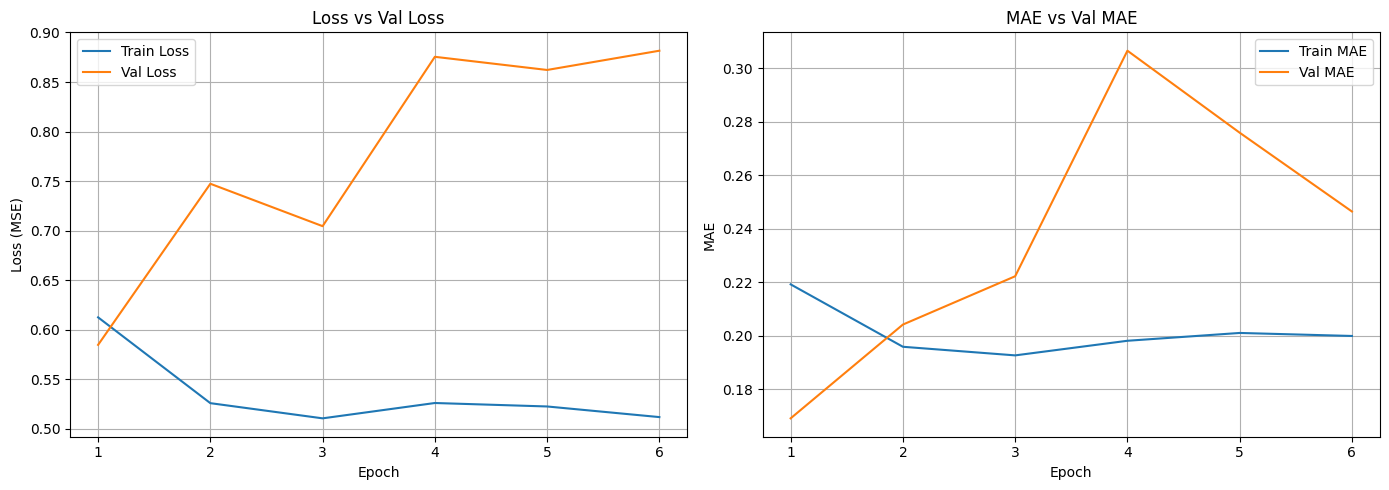

In [5]:
hybrid_model.plot_training_history()

In [6]:
hybrid_model.evaluate(X_test, y_test)

Test loss: 0.5748  |  MAE (scaled): 0.1695


In [7]:
hybrid_model.save_model(name="hybrid_model") 

WindowsPath('C:/Users/sacha/RiceLocal/Capstone/Coding/Flood-Forecasting/models/hybrid_model.keras')